# Mixed death 

### Death Time Maps

In [1]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/esraan/CellDeathSpreading/")

from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mixSpiCalc import mixSpiCalc
import seaborn as sns

In [2]:
exps_dir_name = "/home/esraan/CellDeathSpreading/data/mixed_pure_death_minutes_microns"
meta_data_file_full_path= "/home/esraan/CellDeathSpreading/data/csv_files_minutes_microns_live_only_no_apop.csv"
meta_data_extract_exp_names= pd.read_csv(meta_data_file_full_path)
exp_names = meta_data_extract_exp_names.iloc[:,1]

/tmp/ipykernel_3279591/177113599.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for the colorbar


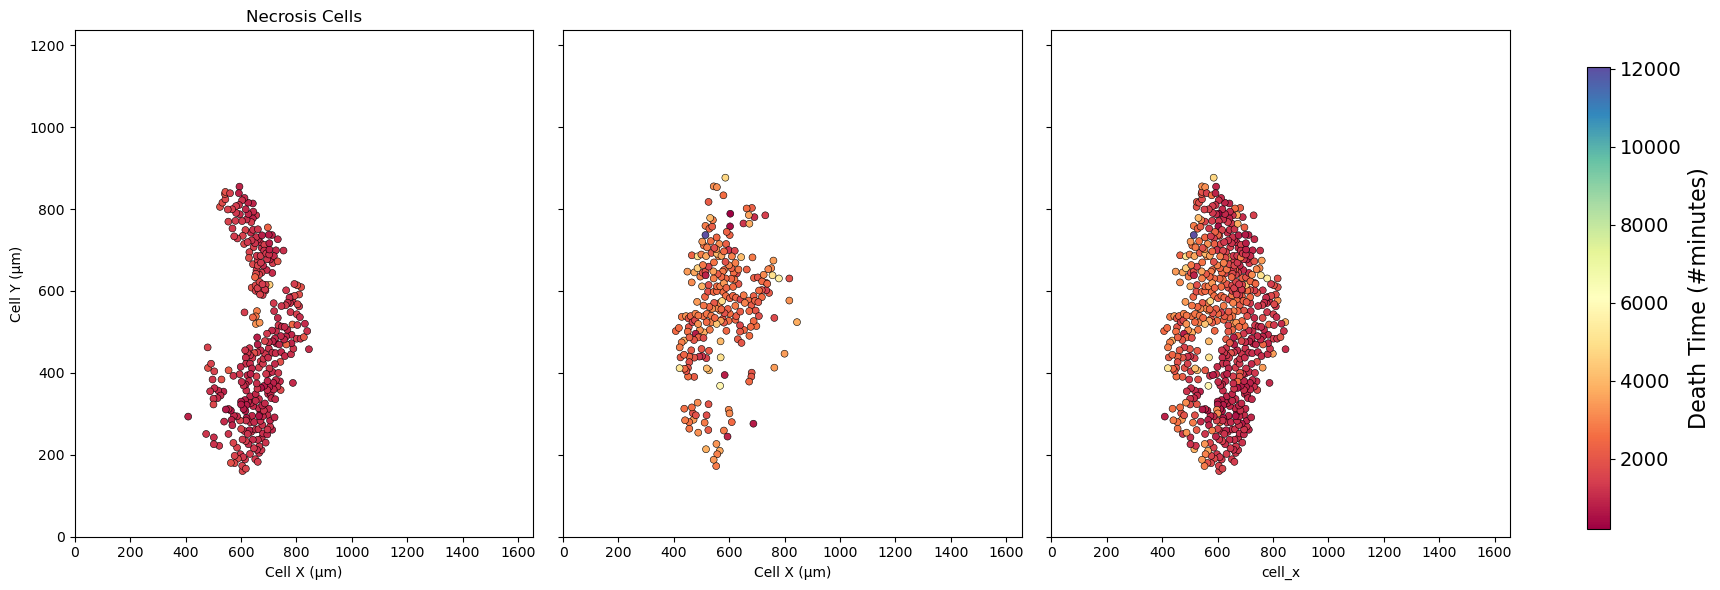

/tmp/ipykernel_3279591/177113599.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for the colorbar


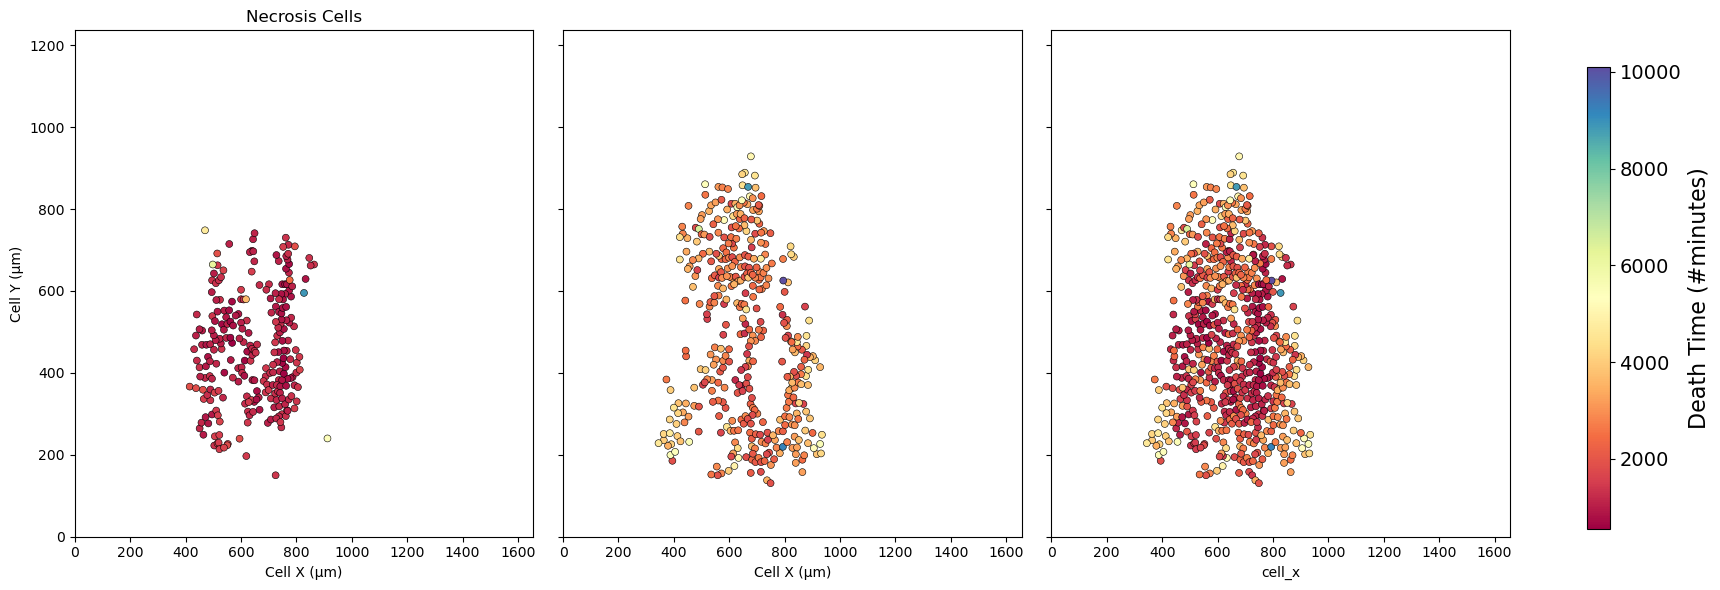

/tmp/ipykernel_3279591/177113599.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for the colorbar


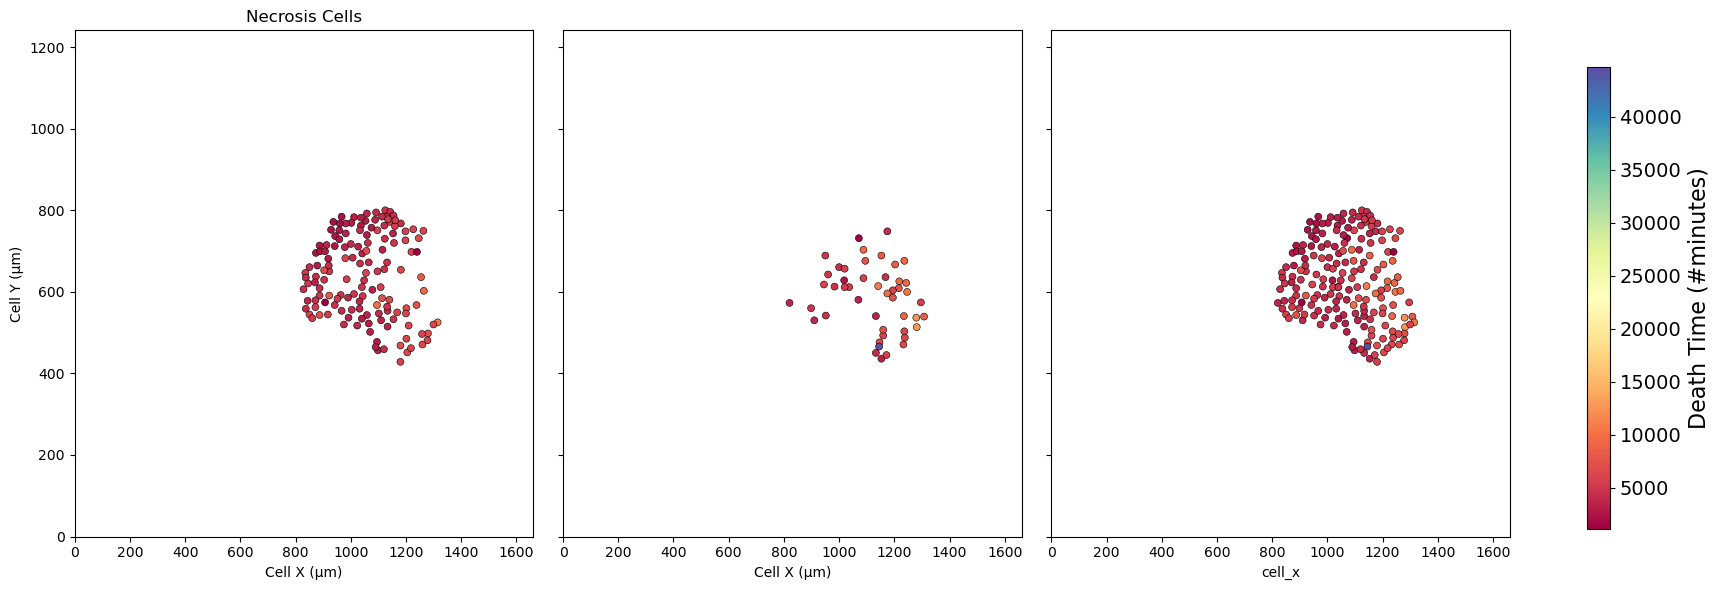

/tmp/ipykernel_3279591/177113599.py:113: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for the colorbar


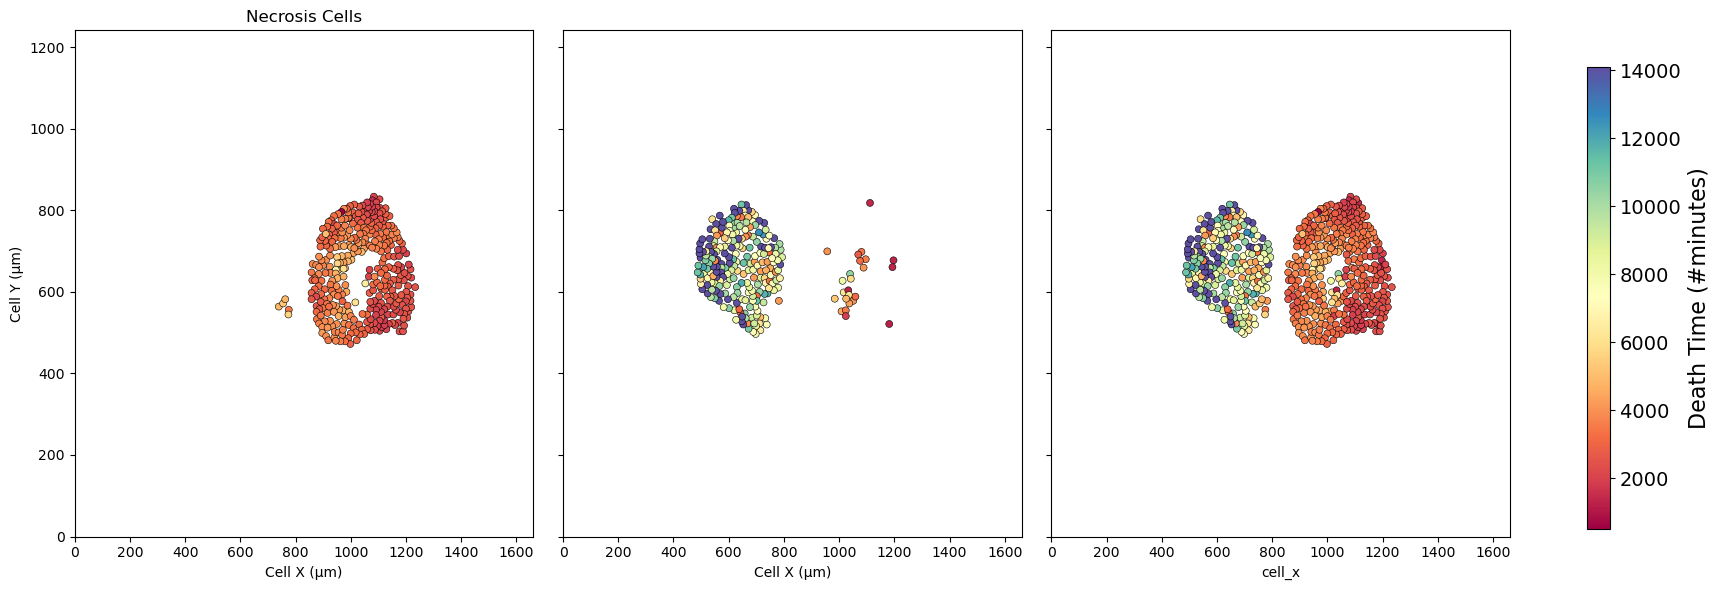

In [3]:
import seaborn as sns
import matplotlib.pyplot as plt
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue
    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue

    # Extract metadata values

    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])
    x_limit = size_x * physical_size_x
    y_limit = size_y * physical_size_y

    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue

    data["death_time"] = metadata["Time Interval (min)"].values[0] * data["death_time"]
    
    # Create a figure and axes for the subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)
    high_value = data["death_time"].max() if not data["death_time"].empty else 0
    # Add a single colorbar outside the plots
    # Normalize the color scale based on the entire dataset's death_time range
    norm = mpl.colors.Normalize(vmin=data["death_time"].min(), vmax=high_value)
    sm = plt.cm.ScalarMappable(cmap="Spectral", norm=norm)
    # Plot 1: Necrosis cells colored by death_time
    scatter1 = sns.scatterplot(
        ax=axs[0],
        data=data[data["Mode"].str.lower() == "necrosis"],
        x="cell_x",
        y="cell_y",
        hue="death_time",
        palette="Spectral",
        edgecolor="black",
        s=25,
        hue_norm=(data["death_time"].min(), high_value)
    )
    axs[0].set_title("Necrosis Cells")
    axs[0].set_xlabel("Cell X (μm)")
    axs[0].set_ylabel("Cell Y (μm)")
    # axs[0].legend(title="Death Time", loc="upper right", bbox_to_anchor=(1.2, 1))

    # Plot 2: Apoptosis cells colored by death_time
    scatter2 = sns.scatterplot(
        ax=axs[1],
        data=data[data["Mode"].str.lower() == "apoptosis"],
        x="cell_x",
        y="cell_y",
        hue="death_time",
        palette="Spectral",
        edgecolor="black",
        s=25,
        hue_norm=(data["death_time"].min(), high_value)
    )
    axs[1].set_xlabel("Cell X (μm)")
    axs[1].set_ylabel("")
    # axs[1].legend(title="Death Time", loc="upper right", bbox_to_anchor=(1.2, 1))

    # Plot 3: Both modes colored by death_time

    scatter3 = sns.scatterplot(
        ax=axs[2],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="death_time",
        palette="Spectral",
        edgecolor="black",
        s=25,
        hue_norm=(data["death_time"].min(), high_value)
    )
    axs[2].set_ylabel("")
    # axs[2].legend(title="Death Time", loc="upper right", bbox_to_anchor=(1.2, 1))

    # Set the same x and y limits for all plots
    for ax in axs:
        legend = ax.get_legend()
        if legend is not None:
            legend.remove()
        ax.set_xlim(0, x_limit)
        ax.set_ylim(0, y_limit)


    # Apply the same color normalization to all subplots
    scatter1.norm = norm
    scatter2.norm = norm
    scatter3.norm = norm
    sm.set_array([])
    cbar = fig.colorbar(sm, ax=axs, orientation='vertical', fraction=0.02, pad=0.1)
    cbar.ax.tick_params(labelsize=14)  # Make font size of colorbar labels bigger
    cbar.set_label("Death Time (#minutes)", fontsize=16)  # Set label with bigger font size

    # Adjust layout
    plt.tight_layout(rect=[0, 0, 0.85, 1])  # Leave space for the colorbar
    plt.show()


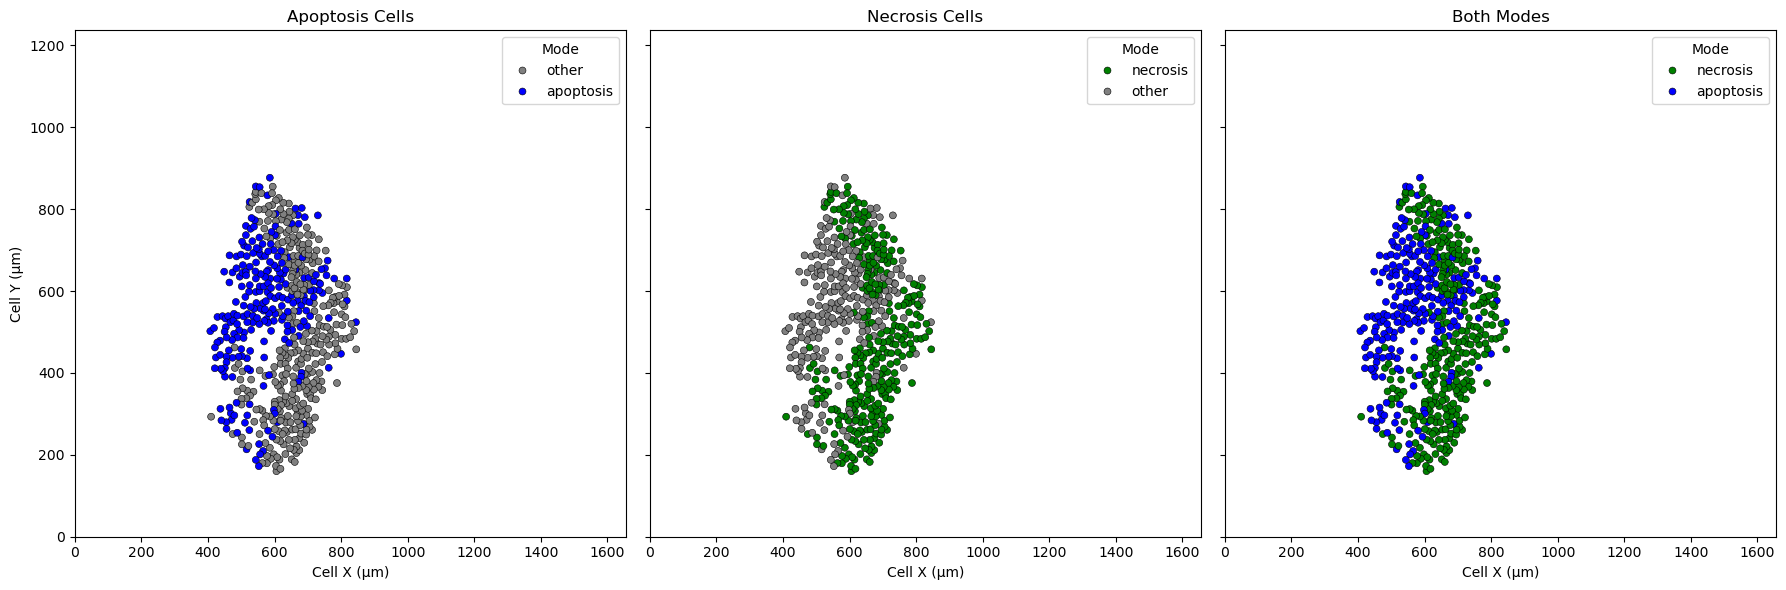

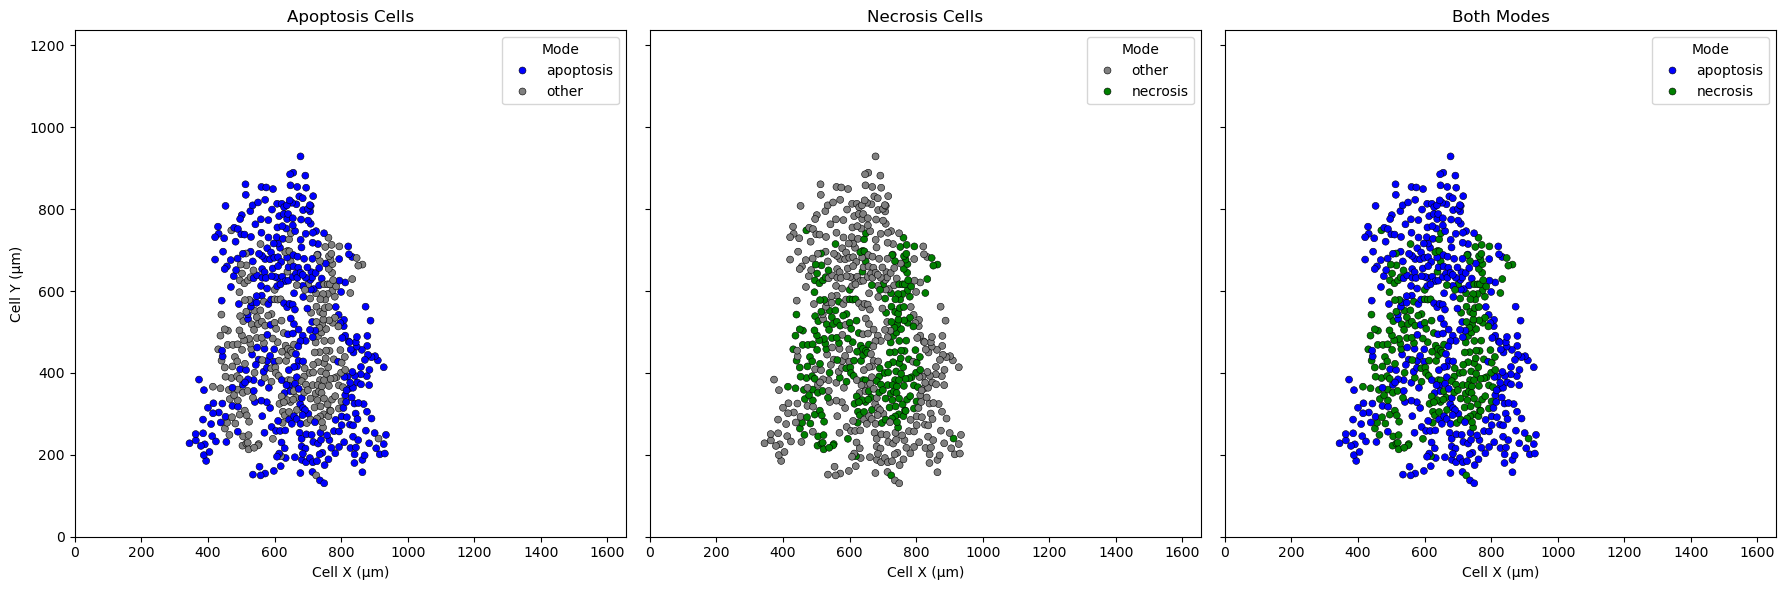

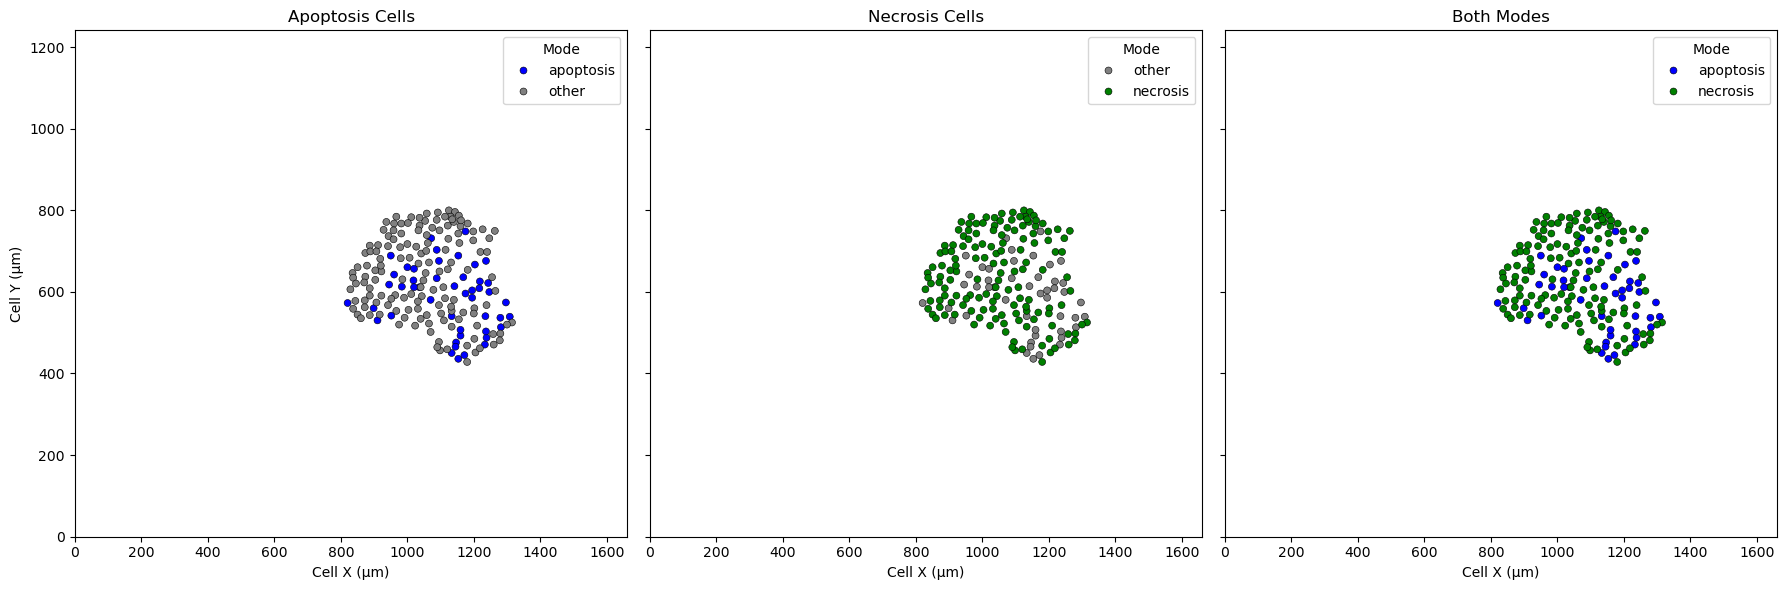

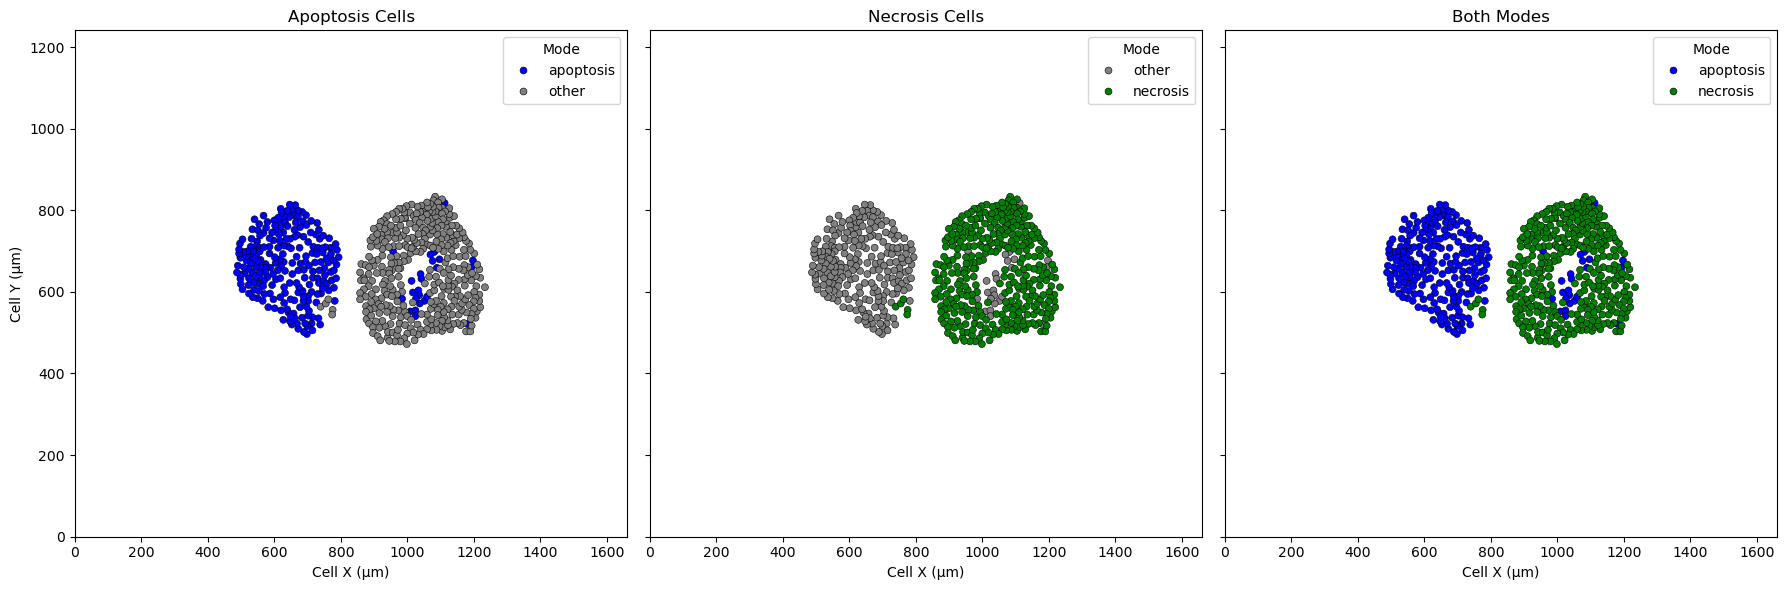

In [6]:
import pandas as pd
import seaborn as sns
import os

import matplotlib.pyplot as plt
custom_palette = {"apoptosis": "blue", "necrosis": "green"}
# Iterate over each file in exp_names
for file_name in exp_names:
    if 'mixed' not in file_name:
        continue  # Skip files that do not contain 'mixed'
    # Get metadata for the current file
    metadata = meta_data_extract_exp_names[meta_data_extract_exp_names["File Name"] == file_name]
    if metadata.empty:
        print(f"Metadata not found for {file_name}. Skipping...")
        continue
    size_x = int(metadata["SizeX"].values[0])
    size_y = int(metadata["SizeY"].values[0])
    physical_size_x = float(metadata["PhysicalSizeX"].values[0])
    physical_size_y = float(metadata["PhysicalSizeY"].values[0])
    x_limit = size_x * physical_size_x
    y_limit = size_y * physical_size_y

    # Construct the full file path
    file_path = os.path.join(exps_dir_name, file_name)
    if not os.path.exists(file_path):
        print(f"File {file_path} not found. Skipping...")
        continue

    # Read the CSV file
    data = pd.read_csv(file_path)
    data = data[data["Mode"].str.lower().isin(["apoptosis", "necrosis", "apoptotic", "necrotic"])]
    legend_labels = {"apoptotic": "apoptosis", "necrotic": "necrosis"}
    data["Mode"] = data["Mode"].replace(legend_labels)
    if data.empty:
        print(f"No valid data in {file_name}. Skipping...")
        continue

    # data["death_time"] = metadata["Time Interval (min)"].values[0] * data["death_time"]
    # Create a figure and axes for the subplots
    fig, axs = plt.subplots(1, 3, figsize=(18, 6), sharex=True, sharey=True)

    # Plot 1: Apoptosis cells in blue, others in grey
    sns.scatterplot(
        ax=axs[0],
        data=data,
        x="cell_x",
        y="cell_y",
        hue=data["Mode"].apply(lambda mode: "apoptosis" if mode == "apoptosis" else "other"),
        palette={"apoptosis": custom_palette["apoptosis"], "other": "grey"},
        edgecolor="black",
        s=25
    )
    axs[0].set_title("Apoptosis Cells")
    axs[0].set_xlabel("Cell X (μm)")
    axs[0].set_ylabel("Cell Y (μm)")
    axs[0].legend(title="Mode", loc="upper right")

    # Plot 2: Necrosis cells in green, others in grey
    sns.scatterplot(
        ax=axs[1],
        data=data,
        x="cell_x",
        y="cell_y",
        hue=data["Mode"].apply(lambda mode: "necrosis" if mode == "necrosis" else "other"),
        palette={"necrosis": custom_palette["necrosis"], "other": "grey"},
        edgecolor="black",
        s=25
    )
    axs[1].set_title("Necrosis Cells")
    axs[1].set_xlabel("Cell X (μm)")
    axs[1].set_ylabel("")

    # Plot 3: Both modes with their respective colors
    sns.scatterplot(
        ax=axs[2],
        data=data,
        x="cell_x",
        y="cell_y",
        hue="Mode",
        palette=custom_palette,
        edgecolor="black",
        s=25
    )
    axs[2].set_title("Both Modes")
    axs[2].set_xlabel("Cell X (μm)")
    axs[2].set_ylabel("")

    # Set the same x and y limits for all plots
    for ax in axs:
        ax.set_xlim(0, x_limit)
        ax.set_ylim(0, y_limit)

    # Adjust layout and show the plots
    plt.tight_layout()
    plt.show()
    

# SPI permuation and p-value

In [4]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/esraan/CellDeathSpreading/")

from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [5]:
def plot_histogram_with_lines(values, observed, shuffled_5_per, bins=30, title="Value Distribution", xlabel="Value", ylabel="Frequency", text=None, text_position=(0.5, 0.9)):
    """
    Plot a histogram of the given values with two vertical lines for precomputed values and optional text.

    Parameters:
    - values: list or array of 1000 numeric values
    - observed: float, position of the first vertical reference line
    - shuffled_5_per: float, position of the second vertical reference line
    - bins: int, number of histogram bins
    - title: str, title of the plot
    - xlabel: str, label for the x-axis
    - ylabel: str, label for the y-axis
    - text: str, optional text to display on the plot
    - text_position: tuple, position of the text in axes coordinates (x, y)
    """

    # Set colorblind-friendly palette
    sns.set_palette("colorblind")
    sns.set_context("talk")  # For better font sizes
    sns.set_style("whitegrid")

    # Create the histogram
    plt.figure(figsize=(12, 6))
    ax = sns.histplot(values, bins=bins, kde=False, color=sns.color_palette("colorblind")[0])

    # Plot vertical lines
    plt.axvline(observed, color=sns.color_palette("colorblind")[2], linestyle="--", linewidth=2, label=f"observed = {observed:.2f}")
    plt.axvline(shuffled_5_per, color=sns.color_palette("colorblind")[1], linestyle="--", linewidth=2, label=f"shuffled 5% = {shuffled_5_per:.2f}")

    # Add text to the plot if provided
    if text:
        plt.text(text_position[0], text_position[1], text, fontsize=14, transform=plt.gca().transAxes, ha='center')

    # Axis labels and title
    plt.title(title, fontsize=20)
    plt.xlabel(xlabel, fontsize=16)
    plt.ylabel(ylabel, fontsize=16)

    # Tick label formatting
    plt.xticks(fontsize=12)
    plt.yticks(fontsize=12)

    # Legend
    plt.legend(fontsize=12, loc="upper right")
    plt.grid(False)
    plt.tight_layout()
    plt.show()


Processing file 1: 7-20-23_10arednuclei_ROI#10_annotation_apop.csv
-0.5362637362637362


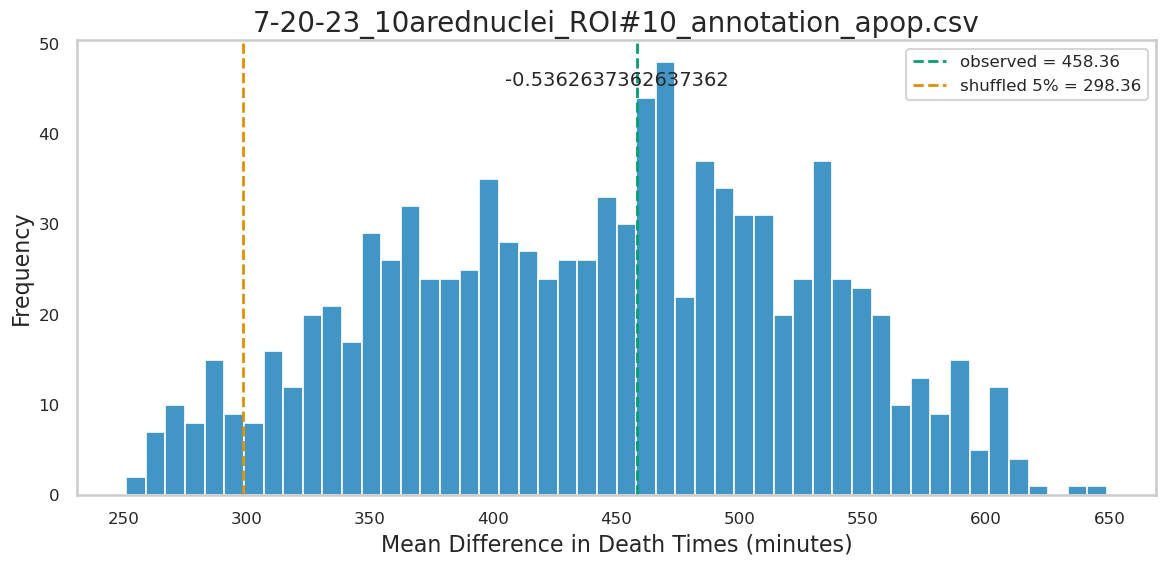

Processing file 4: 7-20-23_10arednuclei_ROI#10_annotation_nec.csv
0.3711605664888726


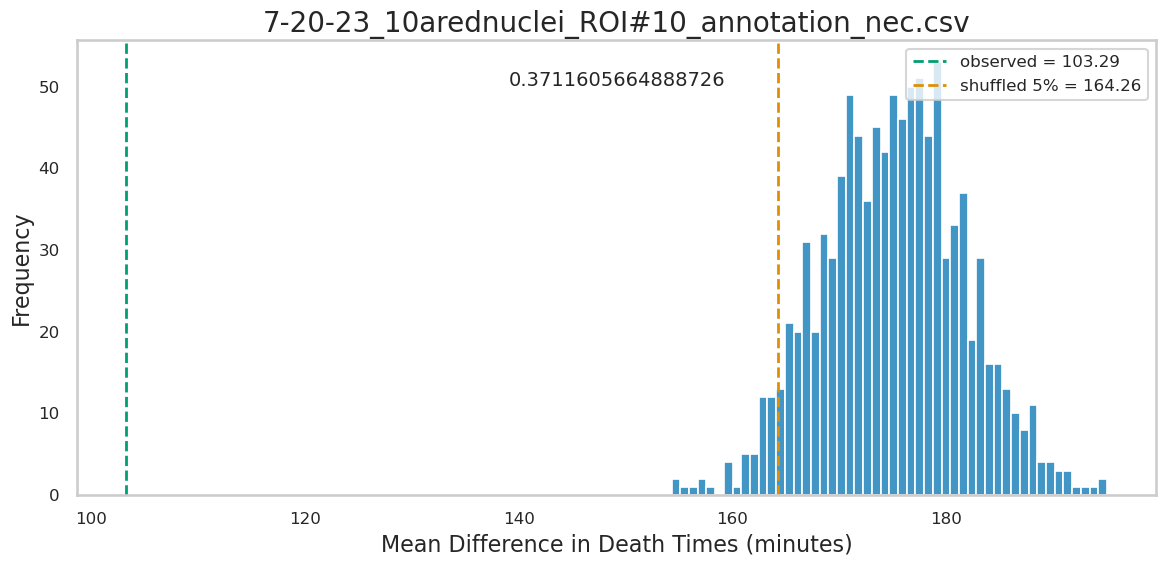

Processing file 8: 7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_nec.csv
0.5764534558082223


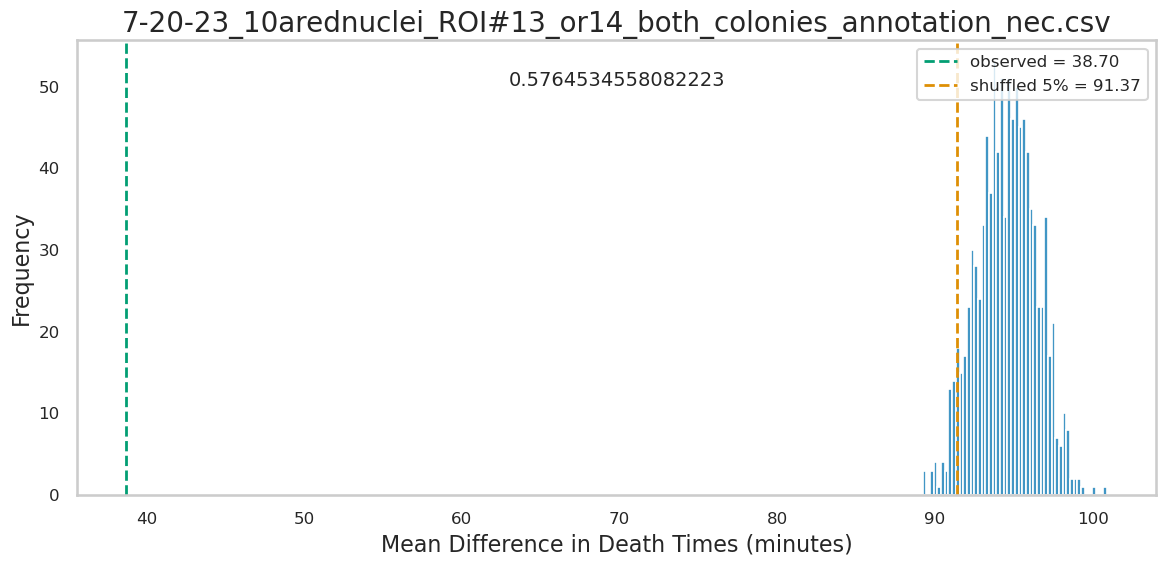

Processing file 9: 7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_apop.csv
0.24973375931842387


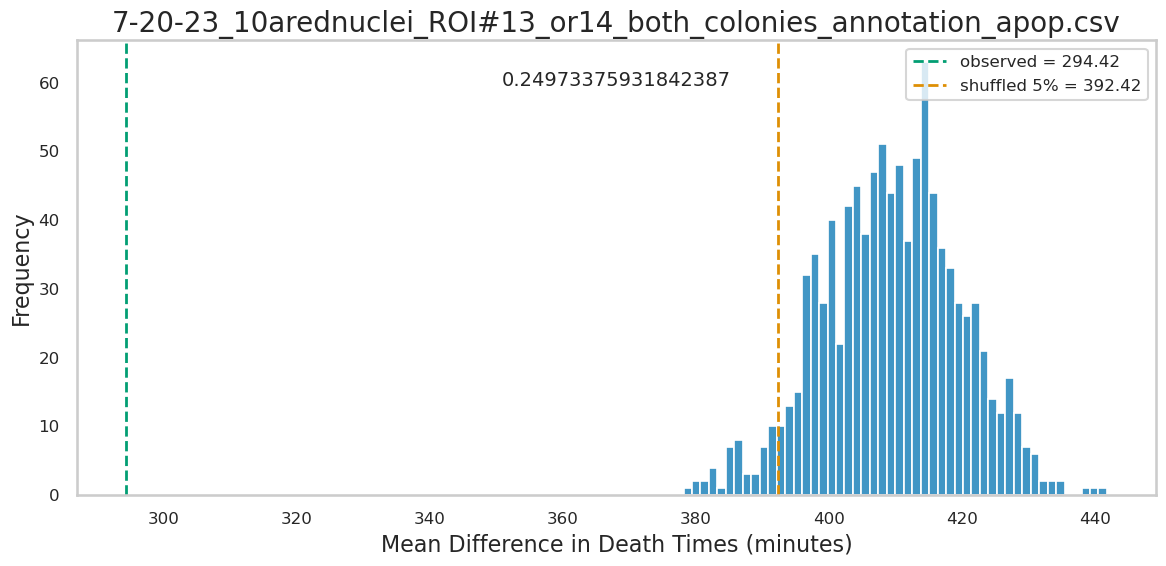

Processing file 11: 3-19-2924_10ah2bmcherry_ROI#2_annotation_nec.csv
0.17145534041224245


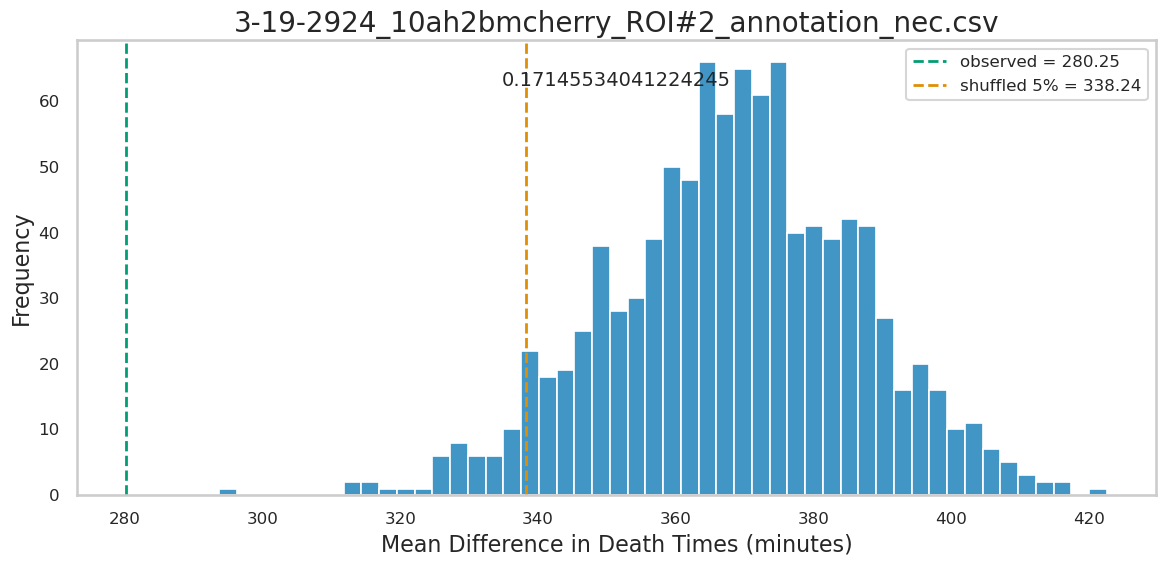

Processing file 17: Field14-002_ROI#1_annotation_apop.csv
0.1701334615847061


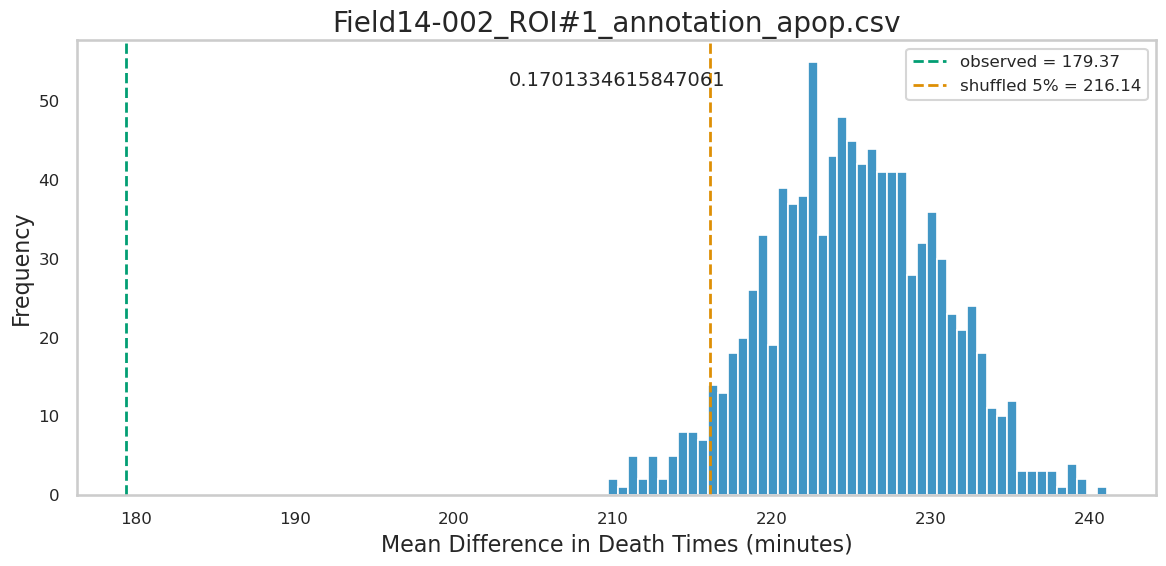

Processing file 21: field13_crop-001_ROI#1_annotation_nec.csv
0.3144649277136082


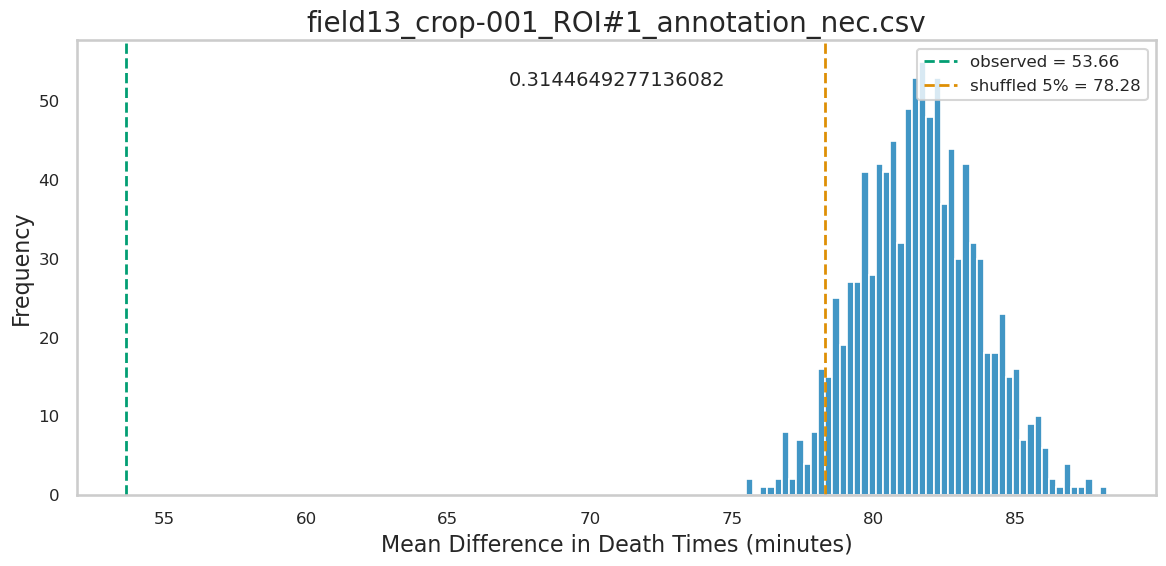

Processing file 22: field13_crop-001_ROI#1_annotation_apop.csv
0.08722639660241753


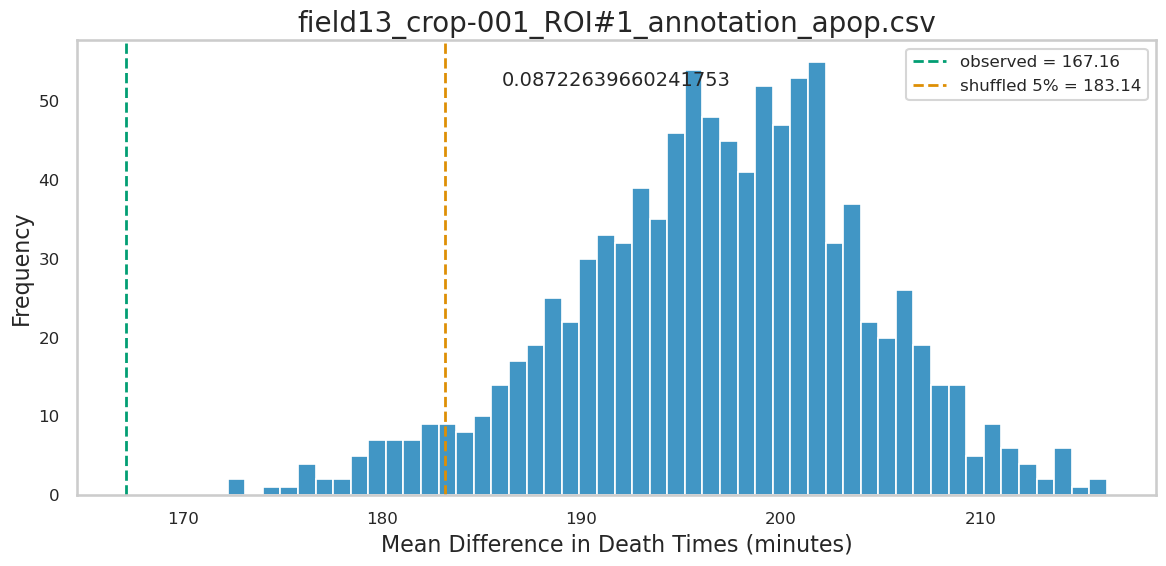

Processing file 24: 3-19-2924_10ah2bmcherry_ROI#2_annotation_apop.csv
-86.0


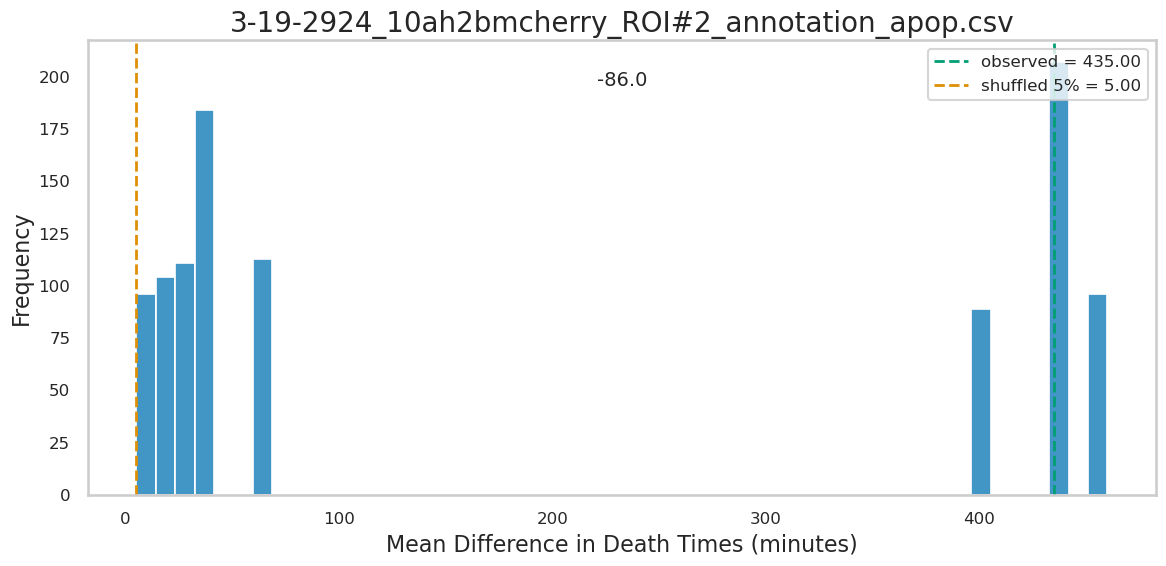

Processing file 28: Field14-002_ROI#1_annotation_nec.csv
0.31506975884690014


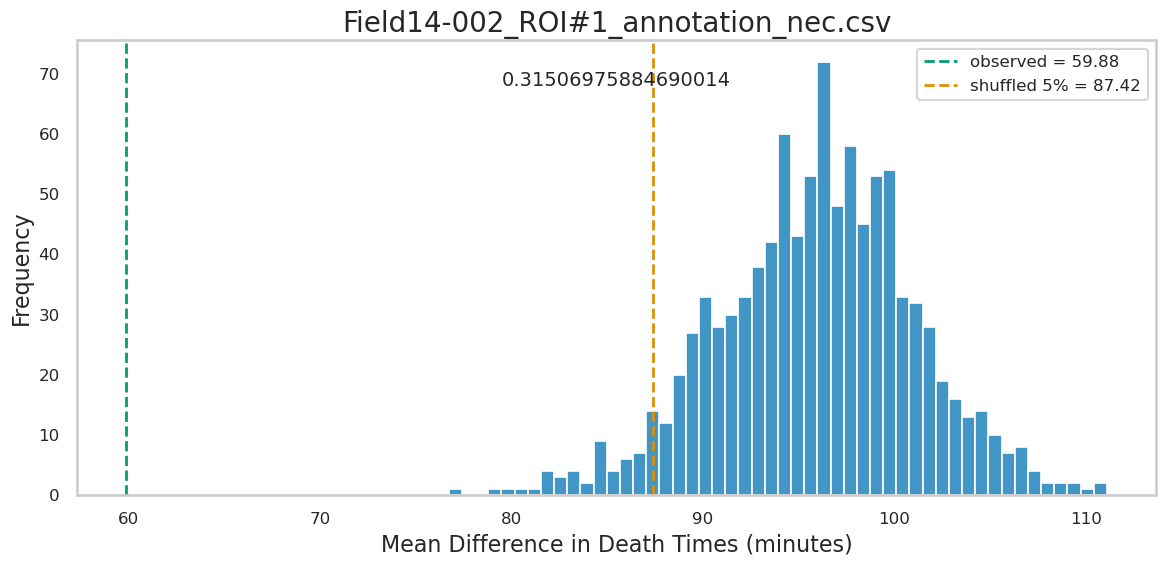

In [16]:
single_exp_full_paths = '/home/esraan/CellDeathSpreading/data/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    if '_mixed' in file or ('nec' not in file and 'apop' not in file):
        continue
    print(f"Processing file {idx+1}: {file}")
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    csv = pd.read_csv(os.path.join(single_exp_full_paths, file))
    death_mode = csv["Mode"].values
    ob = uSpiCalc(XY=cells_loci,
                        die_times=cells_times_of_death,
                        death_mode = death_mode,
                        treatment='ML162',
                        temporal_resolution=10,
                        n_scramble=1000,
                        draw=False,
                        dist_threshold=50, 
                        filter_neighbors_by_distance=True,
                        filter_neighbors_by_level= 1,
                        time_unit='minutes',)
    print(ob.get_uspis())
    mean_of_shuffles = ob.all_mean_shuffles_sorted
    # flattened_array = np.concatenate(mean_of_shuffles).ravel().tolist()
    flattened_array = np.array(mean_of_shuffles)
    # print(flattened_array)
    mean_5_pre =  ob.scramble_signficance_95
    mean_observed = ob.original_difference_death_times
    plot_histogram_with_lines(flattened_array, observed=mean_observed, shuffled_5_per= mean_5_pre, bins=50, title=file, xlabel="Mean Difference in Death Times (minutes)", ylabel="Frequency", text = str(ob.get_uspis()))

# Segregation index permuation and p-value


## Segregation Index

In [1]:
import os
import sys
import shutil
import math
import warnings
from typing import *
from enum import Enum
import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
sys.path.append("/home/esraan/CellDeathSpreading/")

from src.NucleationAndPropagationMeasurements import *
import seaborn as sns
from src.uSpiCalc import uSpiCalc
from src.mSpiCalc import mSpiCalc
from src.mixSpiCalc import mixSpiCalc

In [2]:

single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/mixed_pure_death_minutes_microns/'#Field14-002_ROI#1_annotation_nec.csv'
# single_exp_full_paths = '/sise/assafzar-group/assafzar/Esraa/SalJyoPaperFiles/csv_files_minutes_microns_sytox/'
res = {}
for idx, file in enumerate(os.listdir(single_exp_full_paths)):
    print(file)
    if '_mixed' not in file:
        continue
    # print(file)
    cells_loci, cells_times_of_death = read_experiment_cell_xy_and_death_times(exp_full_path=os.path.join(single_exp_full_paths, file))
    exp_full_path = os.path.join(single_exp_full_paths, file)
    csv_file = pd.read_csv(exp_full_path)
    dist_threshold = 100
    death_modes = csv_file[["Mode"]].values
    # np.random.shuffle(death_modes)
    segregation_index = SegregationIdx(cells_loci, death_modes,1000, dist_threshold, filter_neighbors_by_distance=True, neighbors_level=1, stats_to_calculate= "mean")
    seg_res_dict = segregation_index.get_segregation_index()
    print(seg_res_dict)
    res[file] = {key: ((value[0]/value[2]),value[1]) for key, value in seg_res_dict.items() if key in ('apoptosis', 'necrosis')} #(value[0]/value[2])



3-19-2924_10ah2bmcherry_ROI#2_annotation_nec.csv
Field14-002_ROI#1_annotation_nec.csv
20181227_MCF10A_SKT_xy3.csv
20181227_MCF10A_SKT_xy5.csv
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv
{'apoptosis': (np.float64(0.9302195340501791), np.float64(0.0), np.float64(0.41680672268907565)), 'necrosis': (np.float64(0.9508885686839577), np.float64(0.0), np.float64(0.5831932773109244))}
7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_nec.csv
7-20-23_10arednuclei_ROI#10_annotation_nec.csv
Field14-002_ROI#1_annotation_apop.csv
20181227_MCF10A_SKT_xy4.csv
mixcolony2_field13.csv
Field14-002_ROI#1_annotation_mixed.csv
{'apoptosis': (np.float64(0.792894802584725), np.float64(0.0), np.float64(0.6056338028169014)), 'necrosis': (np.float64(0.6813428316440363), np.float64(0.0), np.float64(0.38967136150234744)), 'mix': (np.float64(0.0), np.float64(0.0), np.float64(0.001564945226917058)), 'entosis': (np.float64(0.19642857142857142), np.float64(0.001), np.float64(0.0031298904

In [3]:
new_res = {'7-20-23_10arednuclei_ROI#13_or14_both_colonies_annotation_mixed.csv': 'field14_two_colony',
'Field14-002_ROI#1_annotation_mixed.csv': 'field14_colony',
'7-20-23_10arednuclei_ROI#10_annotation_mixed.csv': "field11_colony",
'field13_crop-001_ROI#1_annotation_mixed.csv': 'field13_colony'}
plot_res_dict = {new_res.get(key):value for key,value in res.items()}


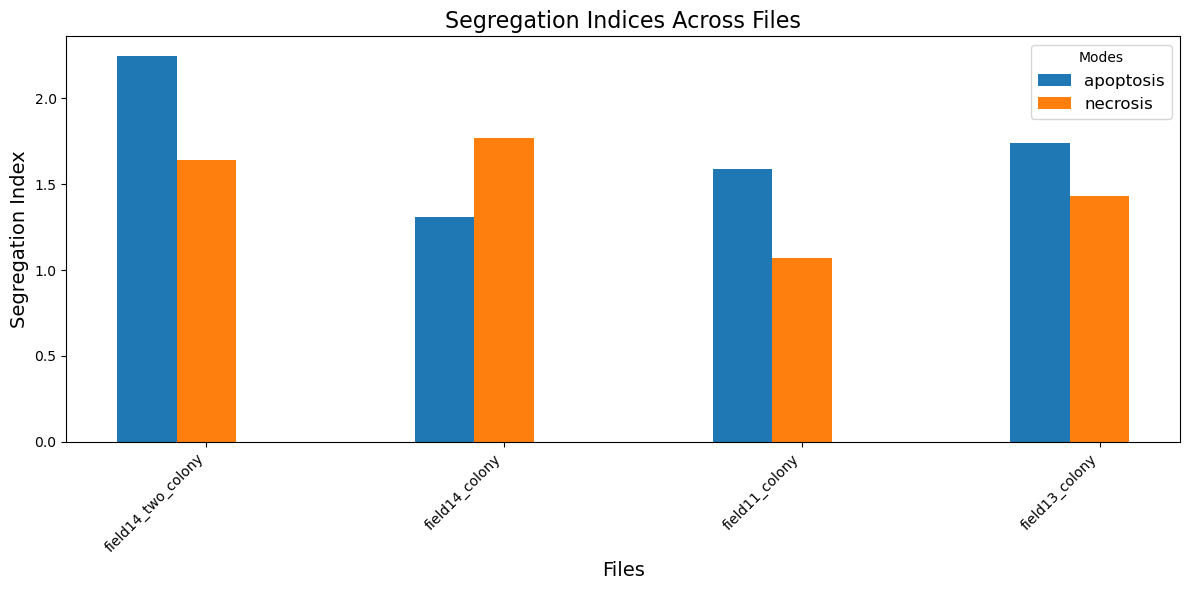

In [25]:
import matplotlib.pyplot as plt

def plot_segregation_indices(res):
    """
    Plots segregation indices for different modes across files.

    Parameters:
    - res: dict, dictionary containing filenames as keys and segregation indices as values
    """
    files = list(res.keys())
    modes = list(res[files[0]].keys())  # Extract modes from the first file
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    x = range(len(files))  # X-axis positions for files
    width = 0.2  # Width of each bar

    plt.figure(figsize=(12, 6))
    for i, mode in enumerate(modes):
        plt.bar([pos + i * width for pos in x], mode_values[mode], width, label=mode)

    plt.xticks([pos + width for pos in x], files, rotation=45, ha='right')
    plt.title("Segregation Indices Across Files", fontsize=16)
    plt.xlabel("Files", fontsize=14)
    plt.ylabel("Segregation Index", fontsize=14)
    plt.legend(title="Modes", fontsize=12)
    plt.tight_layout()
    plt.grid(False)
    plt.show()

# Example usage
plot_segregation_indices(plot_res_dict)

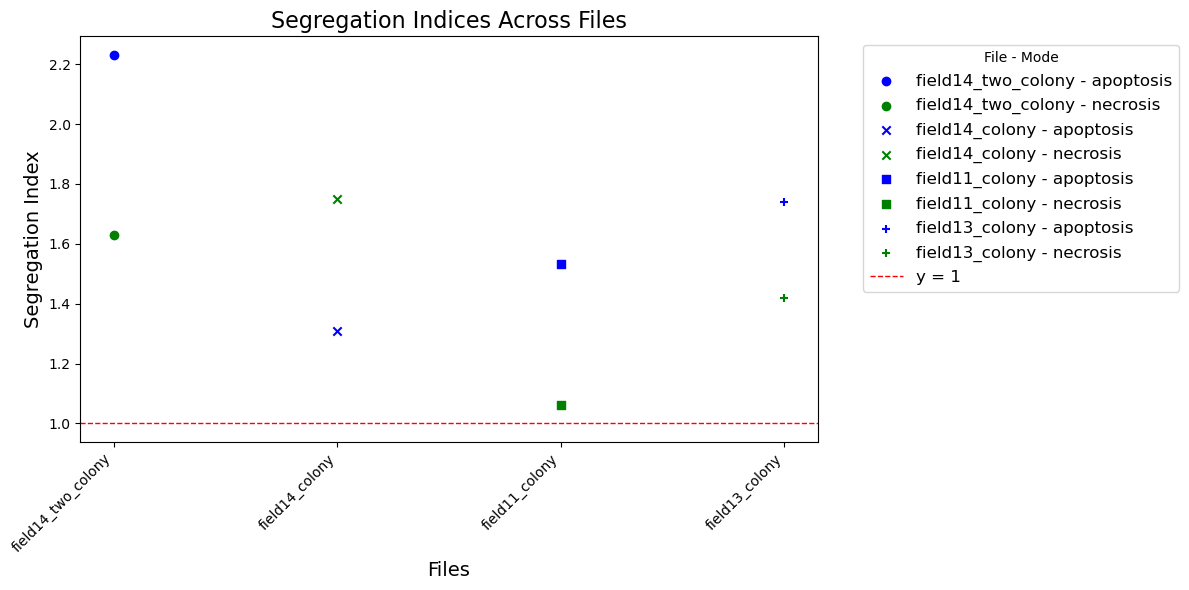

In [29]:
import matplotlib.pyplot as plt

def plot_segregation_indices(res):
    """
    Plots segregation indices for different modes across files using scatter plot.

    Parameters:
    - res: dict, dictionary containing filenames as keys and segregation indices as values
    """
    
    files = list(res.keys())
    modes = list(res[files[0]].keys())  # Extract modes from the first file
    mode_values = {mode: [res[file][mode] for file in files] for mode in modes}

    markers = ['o', 'x', 's', '+', '^', 'v']  # Define markers for files
    colors = ['blue', 'green', 'red', 'orange', 'purple', 'brown']  # Define colors for modes
    mode_color_dict = {mode: colors[i % len(colors)] for i, mode in enumerate(modes)}
    file_marker_dict = {file: markers[i % len(markers)] for i, file in enumerate(files)}

    plt.figure(figsize=(12, 6))
    for file_idx, file in enumerate(files):
        for mode in modes:
            plt.scatter(file_idx, res[file][mode], marker=file_marker_dict[file], color=mode_color_dict[mode], label=f"{file} - {mode}")

    plt.xticks(range(len(files)), files, rotation=45, ha='right')
    plt.title("Segregation Indices Across Files", fontsize=16)
    plt.xlabel("Files", fontsize=14)
    plt.ylabel("Segregation Index", fontsize=14)
    plt.legend(title="File - Mode", fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.tight_layout()
    plt.axhline(y=1, color='red', linestyle='--', linewidth=1, label='y = 1')
    plt.legend(title="File - Mode", fontsize=12, bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.grid(False)
    plt.show()

# Example usage
plot_segregation_indices(plot_res_dict)

## Segregation index

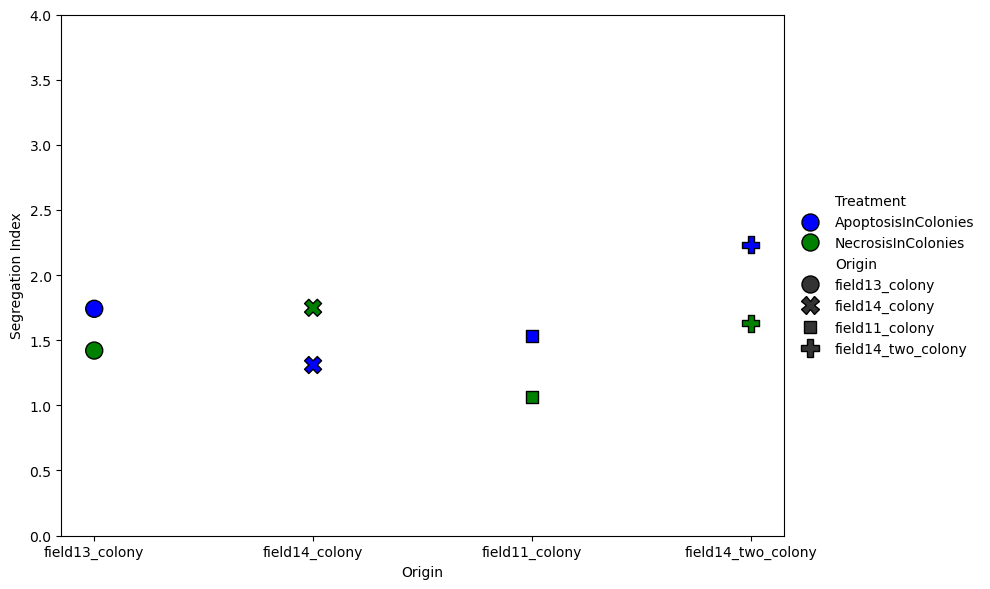

In [17]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=merged_df,
    x="Origin",
    y="segregationIndex",
    hue="Treatment",  # Column to map to colors
    style="Origin",   # Column to map to marker styles
    palette=custom_palette,  # Apply the custom palette
    edgecolor="black",
    linewidth=1,
    s=150,
    ax=ax
)

# Customize labels and legend
ax.set_xlabel("Origin")
ax.set_ylabel("Segregation Index")
# Place the legend outside the plot box
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
ax.set_ylim(0, 4)

plt.tight_layout()
plt.show()


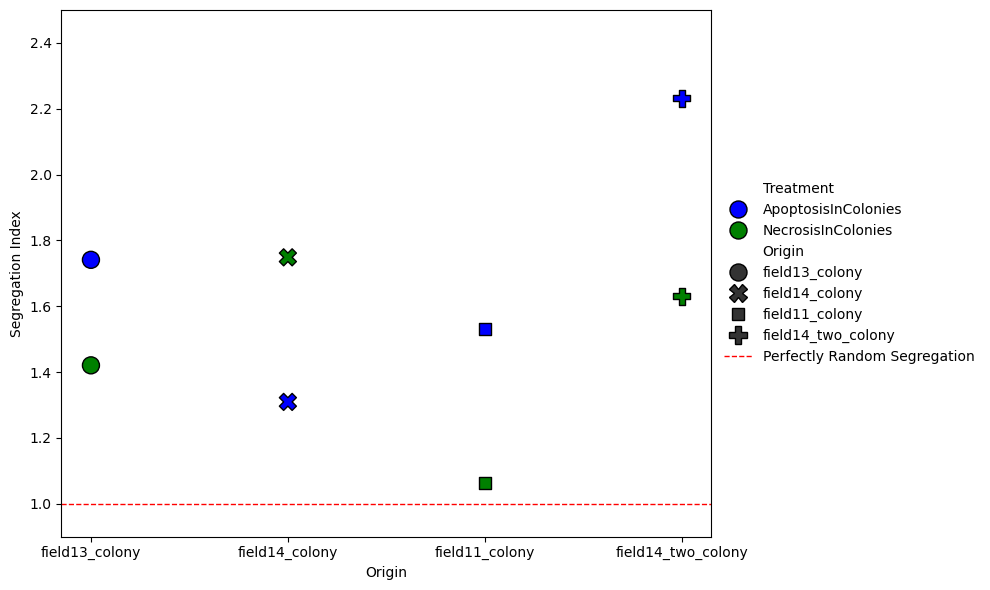

In [34]:
fig, ax = plt.subplots(figsize=(10, 6))

sns.scatterplot(
    data=merged_df,
    x="Origin",
    y="segregationIndex",
    hue="Treatment",  # Column to map to colors
    style="Origin",   # Column to map to marker styles
    palette=custom_palette,  # Apply the custom palette
    edgecolor="black",
    linewidth=1,
    s=150,
    ax=ax
)

# Customize labels and legend
ax.set_xlabel("Origin")
ax.set_ylabel("Segregation Index")
# Place the legend outside the plot box
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
ax.set_ylim(0.9, 2.5)


# Add a red line for y=1, representing perfectly random segregation
ax.axhline(y=1, color='red', linestyle='--', linewidth=1, label='Perfectly Random Segregation')

# Update the legend to include the new line
ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), frameon=False)
plt.tight_layout()
# Add a title for the red line
# ax.text(
#     x=0.7, y=1.02, s="Perfectly Random Segregation (y=1)", 
#     color='red', fontsize=12, ha='center', transform=ax.get_xaxis_transform()
# )

plt.show()